In [1]:
%%HTML
<script src="require.js"></script>

In [2]:
from IPython.display import HTML, display, Markdown, Image

HTML(
    '<script src="https://cdnjs.cloudflare.com/ajax/libs/jquery/2.0.3/'
    'jquery.min.js"></script>'
    '<script>'
    'code_show=true;'
    'function code_toggle(){'
    'if(code_show){'
    "$('div.jp-CodeCell > div.jp-Cell-inputWrapper').hide();"
    '}else{'
    "$('div.jp-CodeCell > div.jp-Cell-inputWrapper').show();"
    '}'
    'code_show=!code_show;'
    '}'
    '$(document).ready(code_toggle);'
    '</script>'
    '<form action="javascript:code_toggle()">'
    '<input type="submit" value="Click here to toggle on/off the raw code.">'
    '</form>'
)

In [7]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, to_date, lit, mean as _mean, date_format,
    input_file_name, regexp_extract, expr
)
from typing import List, Dict, Tuple
import glob, gzip, re
from functools import reduce
import numpy as np

<a id='ExecSum'></a>
<h1 style="color:#ffffff; background-color:#ff5a5f; border: 1px solid #ffffff; padding: 10px 0;">
I. Abstract
</h1>


<a id='Introduction'></a>
<h1 style="color:#ffffff; background-color:#ff5a5f; border: 1px solid #ffffff; padding: 10px 0;">II. Introduction</h1>

<a id='Methodology'></a>
<h1 style="color:#ffffff; background-color:#ff5a5f; border: 1px solid #ffffff; padding: 10px 0;">IV. METHODOLOGY</h1>

<a id='Collection'></a>
<h1 style="color:#ffffff; background-color:#ff5a5f; border: 1px solid #ffffff; padding: 10px 0;">IV. Collect and Preprocess the Data</h1>

<h2 style="color:#00A699">A. Data Source</h2>

The team utilized the InsideAirBnB dataset, which is publicly available through the ‘jojie-collected’ repository in the /mnt/data/public directory maintained by the Asian institute of Management. 

The datasets, located at `/mnt/data/public/insideairbnb/data.insideairbnb.com/`included several cities, but for this project we will be focusing on the United States more specifically New York, Los Angeles, and Chicago. Their data is spread across multiple CSV files, which are large and separated by dates. 

<h2 style="color:#00A699">B. Data Collection and Database Creation</h2>


To gather the listings data, we narrowed the scope to the years `2019`-`2021` and iterated through the file paths

`/mnt/data/public/insideairbnb/data.insideairbnb.com/united-states/ny/new-york-city` (17GB)

`/mnt/data/public/insideairbnb/data.insideairbnb.com/united-states/il/chicago` (2.4GB)

`/mnt/data/public/insideairbnb/data.insideairbnb.com/united-states/ca/los-angeles` (13GB)
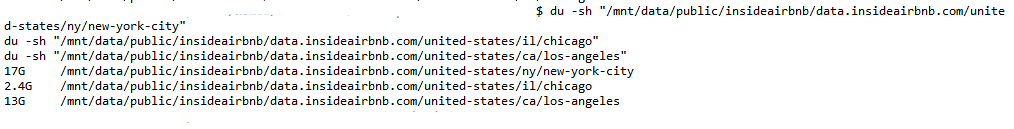

In [9]:
!du -sch /mnt/data/public/insideairbnb/data.insideairbnb.com/united-states/ny/new-york-city

17G	/mnt/data/public/insideairbnb/data.insideairbnb.com/united-states/ny/new-york-city
17G	total


In [11]:
ROOT_DIR = ""
PATH_PREFIX = "mnt/data/public/insideairbnb/data.insideairbnb.com/"

START_DATE = "2016-01-01"
END_DATE = "2025-12-31"

CITY_CONFIGS = [
    {
        "label": "new-york-city",
        "root_path": f"{PATH_PREFIX}united-states/ny/new-york-city",
        "regex_key": "united-states/ny/new-york-city"
    },
    {
        "label": "chicago",
        "root_path": f"{PATH_PREFIX}united-states/il/chicago",
        "regex_key": "united-states/il/chicago"
    },
    {
        "label": "los-angeles",
        "root_path": f"{PATH_PREFIX}united-states/ca/los-angeles",
        "regex_key": "united-states/ca/los-angeles"
    },
]


In [12]:
def read_csv_to_spark(spark, filepath, column, date_pattern):
    match = re.search(date_pattern, filepath)
    if not match:
        return None
    file_date = match.group(1)

    try:
        with gzip.open(filepath, "rt", encoding="utf-8", errors="ignore") as f:
            pdf = pd.read_csv(f, usecols=[column], dtype={column: float})
    except:
        try:
            pdf = pd.read_csv(filepath, usecols=[column], dtype={column: float})
        except:
            return None

    if column not in pdf.columns:
        return None

    pdf["date"] = file_date
    return spark.createDataFrame(pdf)


In [13]:
def collect_daily_metric(
    spark: SparkSession,
    city_configs: List[Dict],
    column: str,
    base_dir: str,
    start_date: str,
    end_date: str,
    is_price: bool = False
):
    print(f"\n=== RUNNING DAILY: {column} ===")
    all_results = []
    daily_col = f"{column}_mean"

    for cfg in city_configs:
        label = cfg["label"]
        root = cfg["root_path"]
        regex = cfg["regex_key"]

        print(f"\n--- {label} ---")

        # PRICE uses visualisations/, others use listings.csv.gz
        if is_price:
            files_pattern = f"{base_dir}/{root}/*/visualisations/listings.csv"
            df = spark.read.option("header", True).option("inferSchema", True) \
                .csv(files_pattern) \
                .withColumn("source_file", input_file_name())
            
            date_pattern = rf"/{regex}/(\d{{4}}-\d{{2}}-\d{{2}})/visualisations/listings.csv"

            df = df.withColumn("date", to_date(
                regexp_extract(col("source_file"), date_pattern, 1),
                "yyyy-MM-dd"
            ))
            df = df.dropna(subset=["date", column])
            df = df.withColumn(column, expr(f"try_cast({column} AS DOUBLE)"))
            df = df.filter(col(column) > 0)

        else:
            files = glob.glob(f"{base_dir}/{root}/*/data/listings.csv.gz")
            print(f"Files found: {len(files)}")

            date_pattern = rf"{regex}/(\d{{4}}-\d{{2}}-\d{{2}})"
            dfs = [read_csv_to_spark(spark, fp, column, date_pattern) for fp in files]
            dfs = [x for x in dfs if x is not None]

            if not dfs:
                print("No readable files.")
                continue

            df = reduce(lambda a, b: a.union(b), dfs)
            df = df.withColumn("date", to_date(col("date"), "yyyy-MM-dd"))
            df = df.filter(col(column).isNotNull())

            # column-specific filters
            if "availability" in column:
                df = df.filter((col(column) >= 0) & (col(column) <= 365))
            if "calculated_host_listings_count" in column:
                df = df.filter(col(column) > 0)

        # Date range filter
        df = df.filter((col("date") >= lit(start_date)) & (col("date") <= lit(end_date)))

        # Aggregate
        daily = (
            df.groupBy("date")
              .agg(_mean(column).alias(daily_col))
              .withColumn("city_label", lit(label))
              .withColumn("month", date_format(col("date"), "yyyy-MM"))
              .orderBy("date")
        )

        all_results.append(daily.toPandas())

    if not all_results:
        return pd.DataFrame()

    return pd.concat(all_results, ignore_index=True)



In [14]:
ROOT_DIR = ""
PATH_PREFIX = "mnt/data/public/insideairbnb/data.insideairbnb.com/"

START_DATE = "2016-01-01"
END_DATE = "2025-12-31"

CITY_CONFIGS = [
    {
        "label": "new-york-city",
        "root_path": f"{PATH_PREFIX}united-states/ny/new-york-city",
        "regex_key": "united-states/ny/new-york-city"
    },
    {
        "label": "chicago",
        "root_path": f"{PATH_PREFIX}united-states/il/chicago",
        "regex_key": "united-states/il/chicago"
    },
    {
        "label": "los-angeles",
        "root_path": f"{PATH_PREFIX}united-states/ca/los-angeles",
        "regex_key": "united-states/ca/los-angeles"
    },
]

In [16]:
def read_csv_to_spark(spark, filepath, column, date_pattern):
    match = re.search(date_pattern, filepath)
    if not match:
        return None
    file_date = match.group(1)

    try:
        with gzip.open(filepath, "rt", encoding="utf-8", errors="ignore") as f:
            pdf = pd.read_csv(f, usecols=[column], dtype={column: float})
    except:
        try:
            pdf = pd.read_csv(filepath, usecols=[column], dtype={column: float})
        except:
            return None

    if column not in pdf.columns:
        return None

    pdf["date"] = file_date
    return spark.createDataFrame(pdf)

In [17]:
def collect_daily_metric(
    spark: SparkSession,
    city_configs: List[Dict],
    column: str,
    base_dir: str,
    start_date: str,
    end_date: str,
    is_price: bool = False
):
    print(f"\n=== RUNNING DAILY: {column} ===")
    all_results = []
    daily_col = f"{column}_mean"

    for cfg in city_configs:
        label = cfg["label"]
        root = cfg["root_path"]
        regex = cfg["regex_key"]

        print(f"\n--- {label} ---")

        # PRICE uses visualisations/, others use listings.csv.gz
        if is_price:
            files_pattern = f"{base_dir}/{root}/*/visualisations/listings.csv"
            df = spark.read.option("header", True).option("inferSchema", True) \
                .csv(files_pattern) \
                .withColumn("source_file", input_file_name())
            
            date_pattern = rf"/{regex}/(\d{{4}}-\d{{2}}-\d{{2}})/visualisations/listings.csv"

            df = df.withColumn("date", to_date(
                regexp_extract(col("source_file"), date_pattern, 1),
                "yyyy-MM-dd"
            ))
            df = df.dropna(subset=["date", column])
            df = df.withColumn(column, expr(f"try_cast({column} AS DOUBLE)"))
            df = df.filter(col(column) > 0)

        else:
            files = glob.glob(f"{base_dir}/{root}/*/data/listings.csv.gz")
            print(f"Files found: {len(files)}")

            date_pattern = rf"{regex}/(\d{{4}}-\d{{2}}-\d{{2}})"
            dfs = [read_csv_to_spark(spark, fp, column, date_pattern) for fp in files]
            dfs = [x for x in dfs if x is not None]

            if not dfs:
                print("No readable files.")
                continue

            df = reduce(lambda a, b: a.union(b), dfs)
            df = df.withColumn("date", to_date(col("date"), "yyyy-MM-dd"))
            df = df.filter(col(column).isNotNull())

            # column-specific filters
            if "availability" in column:
                df = df.filter((col(column) >= 0) & (col(column) <= 365))
            if "calculated_host_listings_count" in column:
                df = df.filter(col(column) > 0)

        # Date range filter
        df = df.filter((col("date") >= lit(start_date)) & (col("date") <= lit(end_date)))

        # Aggregate
        daily = (
            df.groupBy("date")
              .agg(_mean(column).alias(daily_col))
              .withColumn("city_label", lit(label))
              .withColumn("month", date_format(col("date"), "yyyy-MM"))
              .orderBy("date")
        )

        all_results.append(daily.toPandas())

    if not all_results:
        return pd.DataFrame()

    return pd.concat(all_results, ignore_index=True)

In [18]:
def aggregate_monthly(_, daily_df, column):
    if daily_df.empty:
        return pd.DataFrame()

    col = f"{column}_mean"
    month_col = f"{column}_mean_month"

    df = daily_df.copy()
    df["month"] = pd.to_datetime(df["date"]).dt.to_period("M").astype(str)

    monthly = (
        df.groupby(["city_label", "month"])[col]
          .mean()
          .reset_index()
          .rename(columns={col: month_col})
    )

    return monthly

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Tuple
from io import BytesIO
from IPython.display import Image, display

# --- Monthly trend line plot ---
def plot_monthly(city_results: List[Tuple[str, pd.DataFrame]], 
                 column: str, 
                 metric_name: str, 
                 y_label: str, 
                 outfile: str = None):
    """
    Plots monthly average metric by city.
    
    Parameters:
        city_results: list of (city_label, DataFrame) tuples
        column: column name to plot
        metric_name: metric display name
        y_label: y-axis label
        outfile: optional file path to save plot
    """
    plt.figure(figsize=(12, 6))
    
    col_name = f"{column}_mean_month"
    
    for label, data in city_results:
        if data.empty:
            continue
        
        df = data.copy()
        
        # Choose correct column
        current_col_name = col_name if col_name in df.columns else f"{column}_mean"
        if current_col_name not in df.columns:
            print(f"[{label}] Skipping monthly plot: '{current_col_name}' not found.")
            continue
        
        # Determine date column
        date_col = 'month' if 'month' in df.columns else 'date'
        df["month_dt"] = pd.to_datetime(df[date_col], errors='coerce')
        
        # Only include 2021+
        df = df[df["month_dt"] >= "2016-01-01"]
        if df.empty:
            continue
        
        plt.plot(df["month_dt"], df[current_col_name], marker="o", label=label)
    
    plt.xlabel("Month")
    plt.ylabel(y_label)
    plt.title(f"Monthly Average {metric_name} by City (2016–2025)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    
    # Save or display inline
    if outfile:
        try:
            plt.savefig(outfile, dpi=150)
            print(f"Saved figure to {outfile}")
        except Exception as e:
            print(f"Could not save to '{outfile}': {e}")
    else:
        buf = BytesIO()
        plt.savefig(buf, format='png', dpi=150)
        plt.close()
        display(Image(data=buf.getvalue()))
        return buf  # can be reused if needed
    
    plt.show()

# --- Yearly mean bar plot ---
def plot_yearly(city_results: List[Tuple[str, pd.DataFrame]], 
                column: str, 
                metric_name: str, 
                y_label: str, 
                outfile: str = None):
    """
    Plots yearly average metric by city (2016–2025).
    """
    all_rows = []
    
    col_name_monthly = f"{column}_mean_month"
    col_name_daily = f"{column}_mean"
    
    for label, data in city_results:
        if data.empty:
            continue
        
        df = data.copy()
        
        # Choose correct column
        col_to_group = col_name_monthly if col_name_monthly in df.columns else col_name_daily
        if col_to_group not in df.columns:
            print(f"[{label}] Skipping yearly plot: required column not found.")
            continue
        
        date_col = 'month' if 'month' in df.columns else 'date'
        df["year"] = pd.to_datetime(df[date_col], errors='coerce').dt.year
        df = df[df["year"] >= 2016]
        if df.empty:
            continue
        df["year"] = df["year"].astype(str)
        
        yearly = df.groupby("year")[col_to_group].mean()
        # Ensure all years 2021–2025 are present
        yearly = yearly.reindex([str(y) for y in range(2016, 2026)])
        all_rows.append((label, yearly))
    
    if not all_rows:
        print("No data to plot.")
        return
    
    # Plot
    plt.figure(figsize=(10, 6))
    years = [str(y) for y in range(2016, 2026)]
    x = np.arange(len(years))
    bar_width = 0.25
    offset_index = 0
    
    for label, yearly_series in all_rows:
        y_vals = yearly_series.values
        x_positions = x + offset_index * bar_width
        bars = plt.bar(x_positions, y_vals, width=bar_width, label=label)
        
        for bar, value in zip(bars, y_vals):
            if pd.isna(value):
                continue
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                     f"{value:.1f}", ha="center", va="bottom", fontsize=9)
        offset_index += 1
    
    # Center x-ticks under groups
    plt.xticks(x + bar_width * (len(all_rows) - 1) / 2, years)
    plt.ylabel(y_label)
    plt.title(f"Yearly Average {metric_name} (2021–2025)")
    plt.legend()
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    
    if outfile:
        try:
            plt.savefig(outfile, dpi=150)
            print(f"Saved bar chart to {outfile}")
        except Exception as e:
            print(f"Could not save to '{outfile}': {e}")
    else:
        buf = BytesIO()
        plt.savefig(buf, format='png', dpi=150)
        plt.close()
        display(Image(data=buf.getvalue()))
        return buf
    
    plt.show()


# EDA


=== RUNNING DAILY: price ===

--- new-york-city ---

--- chicago ---

--- los-angeles ---
Saved figure to images/monthly_price.png


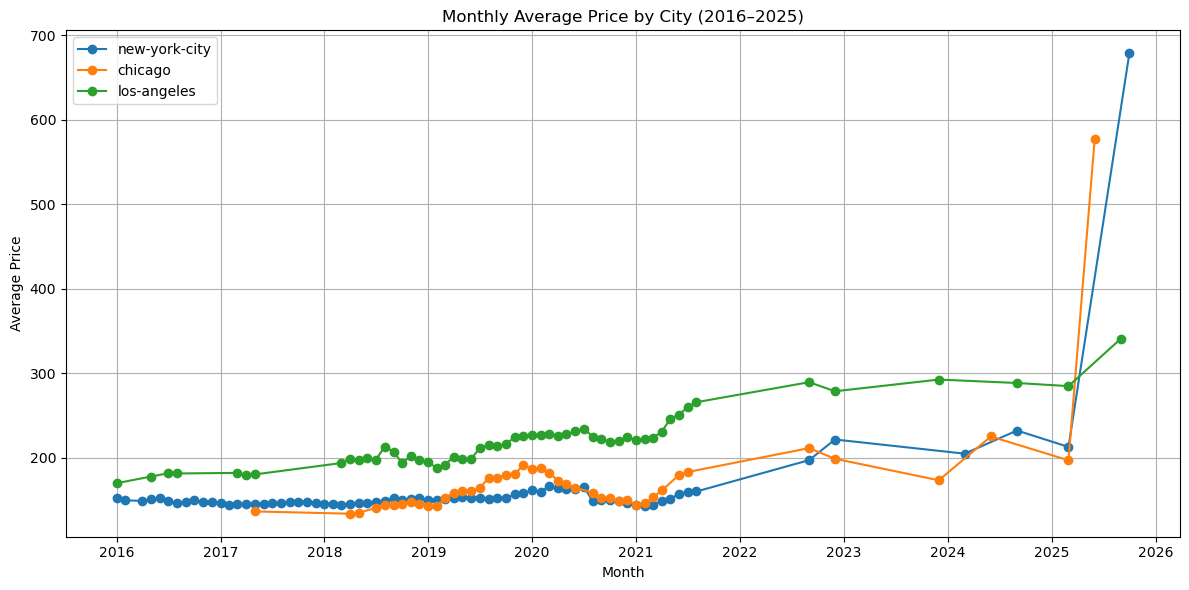

In [20]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("DailyMetrics") \
    .getOrCreate()

price_results = []
avail_results = []
host_results = []

PRICE_COL = "price"
AV_COL = "availability_365"
HOST_COL = "calculated_host_listings_count"

# PRICE --------------------
price_daily = collect_daily_metric(
    spark, CITY_CONFIGS, PRICE_COL, ROOT_DIR,
    START_DATE, END_DATE, is_price=True
)

for city in CITY_CONFIGS:
    df = price_daily[price_daily.city_label == city["label"]]
    monthly = aggregate_monthly(spark, df, PRICE_COL)
    price_results.append((city["label"], monthly))

plot_monthly(price_results, PRICE_COL, "Price", "Average Price", "images/monthly_price.png")

In [21]:
# # AVAILABILITY -------------
# avail_daily = collect_daily_metric(
#     spark, CITY_CONFIGS, AV_COL, ROOT_DIR,
#     START_DATE, END_DATE
# )

# for city in CITY_CONFIGS:
#     df = avail_daily[avail_daily.city_label == city["label"]]
#     avail_results.append((city["label"], df.drop(columns=["city_label"])))

# plot_monthly(avail_results, AV_COL, "Availability", "Avg Availability", "images/availability.png")
# plot_yearly(avail_results, AV_COL, "Availability", "Avg Availability", "images/availability_yearly.png")

In [12]:
# # HOST COUNTS --------------
# host_daily = collect_daily_metric(
#     spark, CITY_CONFIGS, HOST_COL, ROOT_DIR,
#     START_DATE, END_DATE
# )

# for city in CITY_CONFIGS:
#     df = host_daily[host_daily.city_label == city["label"]]
#     monthly = aggregate_monthly(spark, df, HOST_COL)
#     host_results.append((city["label"], monthly))

# plot_monthly(host_results, HOST_COL, "Host Listings", "Host Listings", "images/host_monthly.png")
# plot_yearly(host_results, HOST_COL, "Host Listings", "Host Listings", "images/host_yearly.png")

# spark.stop()

# ML Modeling
